# オラクル

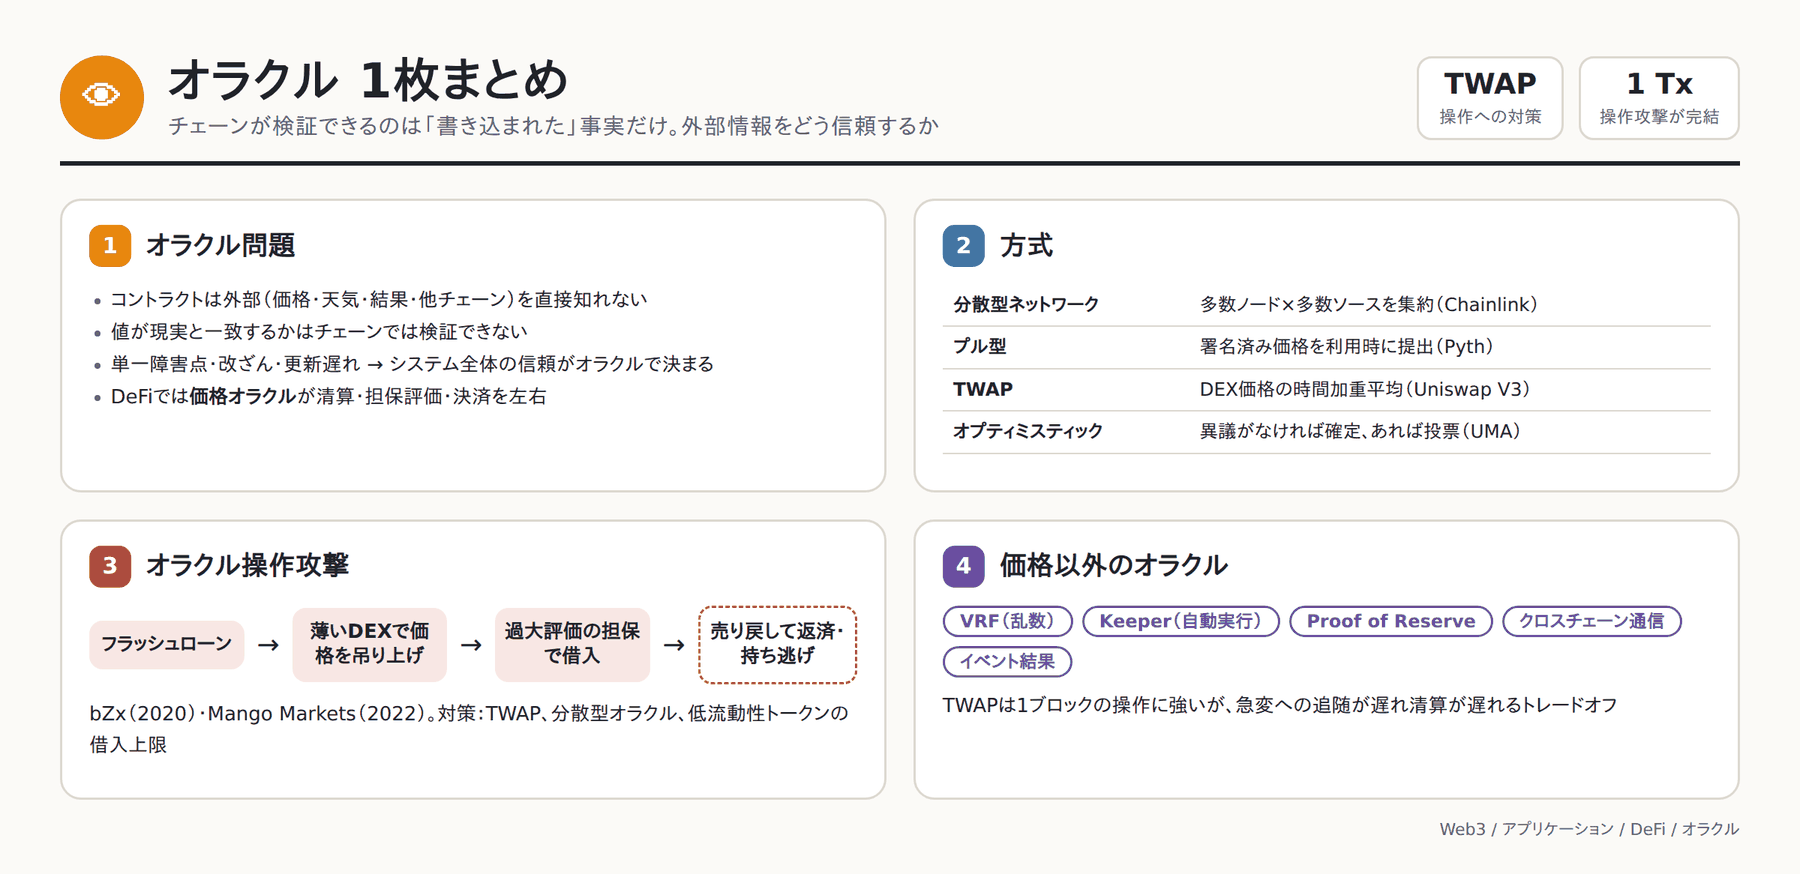

## オラクル問題

ブロックチェーンは閉じた系で、スマートコントラクトは外部の情報（価格、天気、選挙結果、他チェーンの状態など）を直接取得できない。外部の情報をチェーンに書き込む仕組みを **オラクル（oracle）** と呼ぶ。

問題は、チェーンが検証できるのは「オラクルがこの値を書き込んだ」という事実だけで、**その値が現実と一致しているかは検証できない** こと。

- 情報源が1つなら、そこが単一障害点・改ざんの的になる
- 情報の真偽を判定する手段がない
- 更新の遅れ（リアルタイム性の欠如）

せっかくトラストレスなコントラクトを作っても、オラクルを信頼しなければならないなら、システム全体の信頼はオラクルの信頼性で決まってしまう。これを **オラクル問題** と呼ぶ。

DeFiでは特に **価格オラクル** が重要で、レンディングの清算判定やステーブルコインの担保評価、デリバティブの決済は、すべてオラクルの価格に依存している。

## オラクルの方式

| 方式 | 仕組み | 例 |
| --- | --- | --- |
| 中央集権型 | 単一の運営者が値を書き込む | 初期のプロトコル独自のフィード |
| 分散型オラクルネットワーク | 多数の独立したノードが複数の情報源から値を集め、中央値などで集約してオンチェーンに書き込む。ノードはステークやレピュテーションで不正を抑止される | Chainlink |
| プル型 | オフチェーンで署名された価格を、利用者が必要なときにトランザクションに添えて提出する | Pyth, Chainlink Data Streams |
| オンチェーンの価格（TWAP） | DEXのプールの価格を時間加重平均したものを使う | Uniswap V3のTWAPオラクル |
| オプティミスティック型 | 誰かが値を主張し、一定期間内に異議がなければ確定。異議があればトークン保有者の投票で決める | UMA（Polymarketの結果判定に使用） |

### Chainlinkの価格フィード

Chainlinkの価格フィードでは、

1. 複数のノードオペレーターが、それぞれ複数のデータ提供元（取引所やデータ会社）から価格を取得する
2. ノード間で値を集約し、まとめて1つのトランザクションでオンチェーンの集約コントラクトに書き込む
3. 価格が一定以上（例：0.5%）動いたとき、または一定時間（例：1時間）経過したときに更新する

利用者のコントラクトは `latestRoundData()` を呼んで最新の価格を読む。更新時刻も返されるので、古い価格を使わないようにチェックするのが望ましい。

## オラクル操作攻撃

DEXのスポット価格をそのままオラクルとして使うと、**フラッシュローンで一時的に価格を動かして** 攻撃できる。

1. フラッシュローンで大量の資金を借りる
2. 流動性の低いDEXのプールで大量に買い、トークンの価格を吊り上げる
3. そのDEXの価格をオラクルにしているレンディングプロトコルで、値上がりしたトークンを担保に、実際の価値以上の資金を借りる
4. DEXで売り戻して価格を元に戻し、フラッシュローンを返済する
5. 借りた資金はそのまま持ち逃げ（担保は無価値なので返済しない）

これらすべてが1つのトランザクションで完結する。2020年のbZx、2022年のMango Marketsなど、オラクル操作による被害は多い。

対策：

- 1ブロック内のスポット価格ではなく、複数ブロックにわたる **TWAP（時間加重平均価格）** を使う。価格を長時間動かし続けるのはコストが高い
- 複数の独立した情報源を集約した分散型オラクルを使う
- 流動性の低いトークンを担保として受け入れない、または借入上限を低くする

In [1]:
import numpy as np

rng = np.random.default_rng(1)
n_blocks = 30
spot = 100 + np.cumsum(rng.normal(0, 0.3, n_blocks))
spot_attacked = spot.copy()
spot_attacked[-1] *= 3  # 最後のブロックで価格を3倍に操作

window = 10
print(f"スポット価格: 通常 {spot[-1]:.1f} → 操作後 {spot_attacked[-1]:.1f}")
print(f"TWAP({window}ブロック): 通常 {spot[-window:].mean():.1f} → 操作後 {spot_attacked[-window:].mean():.1f}")

スポット価格: 通常 99.4 → 操作後 298.2
TWAP(10ブロック): 通常 99.9 → 操作後 119.7


TWAPは1ブロックだけの操作には強いが、操作の影響を薄めるだけで消すわけではない。また、急激な市場変動への追随が遅れるため、清算が遅れるというトレードオフがある。

## 価格以外のオラクル

| 種類 | 用途 |
| --- | --- |
| VRF（検証可能な乱数） | NFTのランダムな特性の決定、ゲーム、抽選 |
| 自動実行（Keeper） | 清算、定期的なリバランスなど、コントラクトの関数を条件に応じて呼び出す |
| Proof of Reserve | ステーブルコインやラップドトークンの裏付け資産の残高を確認する |
| クロスチェーン通信 | 他のチェーンの状態やメッセージを中継する（→[インターオペラビリティ](../../scaling/interoperability.ipynb)） |
| イベントの結果 | 予測市場や保険の支払い条件の判定（→[予測市場](../prediction_markets.ipynb)） |

## 参考文献

- Caldarelli, G. (2020). [Understanding the Blockchain Oracle Problem: A Call for Action](https://doi.org/10.3390/info11110509). Information.
- [Chainlink Documentation](https://docs.chain.link/)
- [UMA Optimistic Oracle](https://docs.uma.xyz/)